In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, recall_score

# Set style for plots
sns.set_style("whitegrid")

In [3]:
url = 'https://raw.githubusercontent.com/MohammadErfanRashidi/Customer-Churn/refs/heads/main/data/Customer-Churn_Processed.csv'
df = pd.read_csv(url)

# Quick look at the data
print("Shape:", df.shape)
df.head()

Shape: (7021, 32)


,SeniorCitizen,Partner_Num,Dependents_Num,PhoneService_Num,PaperlessBilling_Num,Gender_Num,Churn_Num,MultipleLines_Encoded,InternetService_Encoded,OnlineSecurity_Encoded,...,HasDSL,HasOnlineSecurity,HasTechSupport,TotalServices,HasPartnerOrDependents,tenure_Scaled,MonthlyCharges_Scaled,ServiceCount_Scaled,AvgMonthlySpend_Scaled,TotalCharges_Scaled
0,0,1,0,0,1,0,0,0,0,0,...,1,0,0,1,1,-1.282637,-1.164052,-1.174157,-1.447328,-0.995615
1,0,0,0,1,0,1,0,1,0,1,...,1,0,0,5,0,0.062382,-0.262792,-0.428071,-0.168120,-0.175249
2,0,0,0,1,1,1,1,1,0,1,...,1,0,0,3,0,-1.241879,-0.365888,-0.925461,-0.755501,-0.961074
3,0,0,0,0,0,1,0,0,0,1,...,1,0,0,5,0,0.510722,-0.750005,-0.179375,-0.625607,-0.196755
4,0,0,0,1,1,0,1,1,1,0,...,0,0,0,3,0,-1.241879,0.194490,-0.925461,-0.280637,-0.941884


Churn_Num
0    5164
1    1857
Name: count, dtype: int64

Churn rate: 26.45%


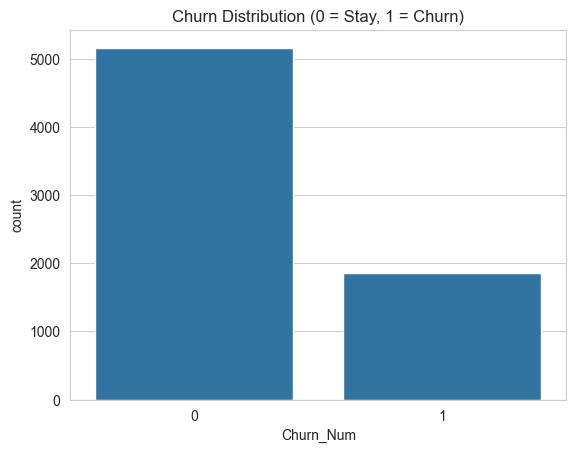

In [4]:
# The target column is 'Churn_Num'
churn_counts = df['Churn_Num'].value_counts()
print(churn_counts)
print(f"\nChurn rate: {churn_counts[1] / len(df):.2%}")

# Visualize imbalance
sns.countplot(x='Churn_Num', data=df)
plt.title('Churn Distribution (0 = Stay, 1 = Churn)')
plt.show()

In [5]:
# Drop the target column to get features
X = df.drop('Churn_Num', axis=1)
y = df['Churn_Num']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7021, 31)
Target shape: (7021,)


In [6]:
# Split data (stratify to maintain class proportions in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate:  {y_test.mean():.2%}")

Train size: 5616, Test size: 1405
Train churn rate: 26.44%
Test churn rate:  26.48%


In [7]:
# Create logistic regression object
logreg = LogisticRegression(
    class_weight='balanced',  # Automatically adjust weights inversely proportional to class frequencies
    max_iter=1000,
    random_state=42
)

# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],          # Regularization strength
    'penalty': ['l1', 'l2'],                # Type of regularization
    'solver': ['liblinear', 'saga']         # Solvers that support both l1 and l2
}

# Grid search with recall as the scoring metric
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring='recall',
    cv=5,                    # 5-fold cross-validation
    n_jobs=-1,               # Use all available cores
    verbose=1
)

# Fit the grid search
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation recall: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}
Best cross-validation recall: 0.8108


C:\Users\erfan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\erfan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Test Recall: 0.7876


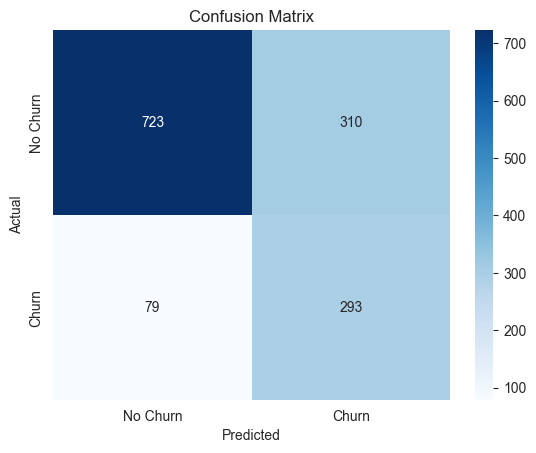


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.60       372

    accuracy                           0.72      1405
   macro avg       0.69      0.74      0.69      1405
weighted avg       0.79      0.72      0.74      1405



In [8]:
# Get the best model
best_model = grid_search.best_estimator_

# Predict on test data
y_pred = best_model.predict(X_test)

# Calculate recall on test set
test_recall = recall_score(y_test, y_pred)
print(f"Test Recall: {test_recall:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Top 10 most influential features (by absolute coefficient):
                   Feature  Coefficient
14        Contract_Encoded    -0.727869
16             TenureGroup    -0.350797
20           HasFiberOptic     0.323831
17             ChargeGroup     0.270619
15   PaymentMethod_Encoded    -0.152692
8   OnlineSecurity_Encoded    -0.115163
26           tenure_Scaled    -0.099676
27   MonthlyCharges_Scaled     0.073141
24           TotalServices    -0.072961
4     PaperlessBilling_Num     0.000878


C:\Users\erfan\AppData\Local\Temp\ipykernel_20536\1863972947.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='Coefficient', y='Feature', palette='coolwarm')


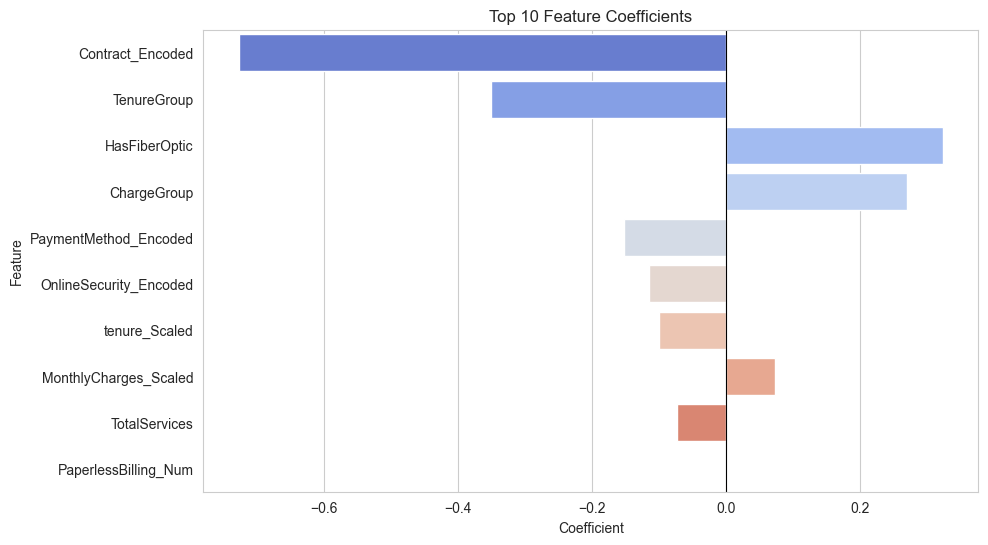

In [9]:
# For logistic regression, coefficients indicate feature importance (direction and magnitude)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Top 10 most influential features (by absolute coefficient):")
print(coefficients.head(10))

# Visualize top coefficients
plt.figure(figsize=(10,6))
top_features = coefficients.head(10)
sns.barplot(data=top_features, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Top 10 Feature Coefficients')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

In [10]:
# Create a copy of the original dataframe for feature engineering
df_fe = df.copy()

# 1. Interaction between Contract and Tenure (both strong predictors)
#    Month-to-month (Contract_Encoded=0) + low tenure = high risk
df_fe['Contract_Tenure_Interaction'] = df_fe['Contract_Encoded'] * df_fe['tenure_Scaled']

# 2. Flag for high-risk combination: Fiber optic + Month-to-month + High monthly charges
#    (using median of MonthlyCharges_Scaled as threshold for "high")
median_charge = df_fe['MonthlyCharges_Scaled'].median()
df_fe['HighRisk_Flag'] = ((df_fe['HasFiberOptic'] == 1) & 
                          (df_fe['Contract_Encoded'] == 0) & 
                          (df_fe['MonthlyCharges_Scaled'] > median_charge)).astype(int)

# 3. Ratio of tenure to monthly charges (long tenure with low charges = sticky)
#    Add small constant to avoid division by zero
df_fe['Tenure_Charge_Ratio'] = df_fe['tenure_Scaled'] / (df_fe['MonthlyCharges_Scaled'] + 0.001)

# 4. Online security and tech support combined (both protective)
df_fe['Security_Tech_Support'] = df_fe['HasOnlineSecurity'] + df_fe['HasTechSupport']

# Quick check of new features
print("New features added:")
print(df_fe[['Contract_Tenure_Interaction', 'HighRisk_Flag', 'Tenure_Charge_Ratio', 'Security_Tech_Support']].head())

New features added:
   Contract_Tenure_Interaction  HighRisk_Flag  Tenure_Charge_Ratio  \
0                    -0.000000              0             1.102819   
1                     0.062382              0            -0.238290   
2                    -0.000000              0             3.403449   
3                     0.510722              0            -0.681868   
4                    -0.000000              1            -6.352661   

   Security_Tech_Support  
0                      0  
1                      0  
2                      0  
3                      0  
4                      0  


In [11]:
from imblearn.under_sampling import RandomUnderSampler

# Re-define X and y with new features
X_new = df_fe.drop('Churn_Num', axis=1)
y_new = df_fe['Churn_Num']

# Split first (before any resampling) to avoid data leakage
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

print(f"Original training shape: {X_train_new.shape}")
print(f"Original training churn distribution:\n{y_train_new.value_counts()}")

# Apply RandomUnderSampler to training data only
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_new, y_train_new)

print(f"\nAfter undersampling training shape: {X_train_rus.shape}")
print(f"After undersampling churn distribution:\n{y_train_rus.value_counts()}")

Original training shape: (5616, 35)
Original training churn distribution:
Churn_Num
0    4131
1    1485
Name: count, dtype: int64

After undersampling training shape: (2970, 35)
After undersampling churn distribution:
Churn_Num
0    1485
1    1485
Name: count, dtype: int64


In [12]:
# Same parameter grid, but now on undersampled data
logreg_rus = LogisticRegression(max_iter=1000, random_state=42)

# Note: class_weight is not needed here because the data is balanced
param_grid_rus = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search_rus = GridSearchCV(
    estimator=logreg_rus,
    param_grid=param_grid_rus,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_rus.fit(X_train_rus, y_train_rus)

print("Best parameters (undersampled):", grid_search_rus.best_params_)
print(f"Best CV recall (undersampled): {grid_search_rus.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters (undersampled): {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV recall (undersampled): 0.7987


C:\Users\erfan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\erfan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Test Recall (with undersampling + new features): 0.7984


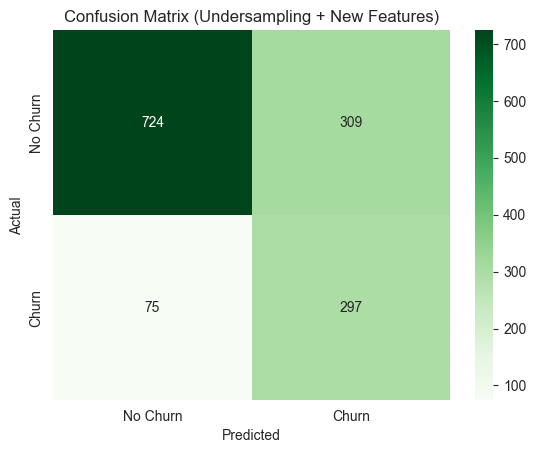


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.70      0.79      1033
       Churn       0.49      0.80      0.61       372

    accuracy                           0.73      1405
   macro avg       0.70      0.75      0.70      1405
weighted avg       0.80      0.73      0.74      1405



In [13]:
best_model_rus = grid_search_rus.best_estimator_
y_pred_rus = best_model_rus.predict(X_test_new)

# Recall on test set
test_recall_rus = recall_score(y_test_new, y_pred_rus)
print(f"Test Recall (with undersampling + new features): {test_recall_rus:.4f}")

# Confusion matrix
cm_rus = confusion_matrix(y_test_new, y_pred_rus)
sns.heatmap(cm_rus, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Undersampling + New Features)')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_rus, target_names=['No Churn', 'Churn']))

In [16]:
from sklearn.metrics import precision_score, f1_score

# Compare recall and precision for churn class
print("Model Comparison (Churn Class):")
print("-" * 45)
print(f"{'Metric':<15} {'Baseline':<12} {'Undersampled+Features':<12}")
print("-" * 45)
print(f"{'Recall':<15} {0.79:<12} {test_recall_rus:.2f}")
print(f"{'Precision':<15} {0.49:<12} {precision_score(y_test_new, y_pred_rus):.2f}")
print(f"{'F1-score':<15} {0.60:<12} {f1_score(y_test_new, y_pred_rus):.2f}")

Model Comparison (Churn Class):
---------------------------------------------
Metric          Baseline     Undersampled+Features
---------------------------------------------
Recall          0.79         0.80
Precision       0.49         0.49
F1-score        0.6          0.61


In [17]:
# Get predicted probabilities instead of hard classes
y_probs = best_model_rus.predict_proba(X_test_new)[:, 1]

# Try a lower threshold (e.g., 0.3 instead of 0.5)
threshold = 0.3
y_pred_thresh = (y_probs >= threshold).astype(int)

print(f"Threshold = {threshold}")
print(f"Recall:    {recall_score(y_test_new, y_pred_thresh):.4f}")
print(f"Precision: {precision_score(y_test_new, y_pred_thresh):.4f}")

Threshold = 0.3
Recall:    0.9516
Precision: 0.3831


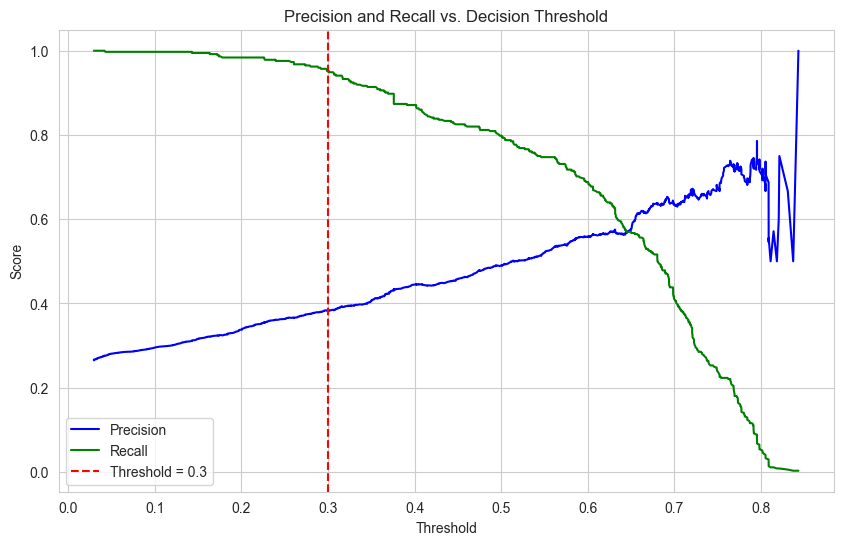

To achieve ≥90% recall, use threshold ≤ 0.030
Precision at that threshold: 0.265


In [18]:
from sklearn.metrics import precision_recall_curve

# Get probabilities for the positive class
y_probs = best_model_rus.predict_proba(X_test_new)[:, 1]

# Calculate precision and recall for all thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_new, y_probs)

# Plot
plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions[:-1], 'b-', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs. Decision Threshold')
plt.legend()
plt.grid(True)

# Highlight threshold = 0.3
plt.axvline(x=0.3, color='r', linestyle='--', label='Threshold = 0.3')
plt.legend()
plt.show()

# Find threshold that gives at least 90% recall with highest precision
target_recall = 0.90
idx = np.where(recalls >= target_recall)[0][0]
best_threshold = thresholds[idx]
best_precision = precisions[idx]

print(f"To achieve ≥{target_recall:.0%} recall, use threshold ≤ {best_threshold:.3f}")
print(f"Precision at that threshold: {best_precision:.3f}")

In [21]:
# Save the model
import pickle

with open('churn_logreg_model.pkl', 'wb') as f:
    pickle.dump(best_model_rus, f)